Dataset size: 7255
Input batch shape: torch.Size([4, 9, 360, 640])
Heatmap batch shape: torch.Size([4, 1, 360, 640])


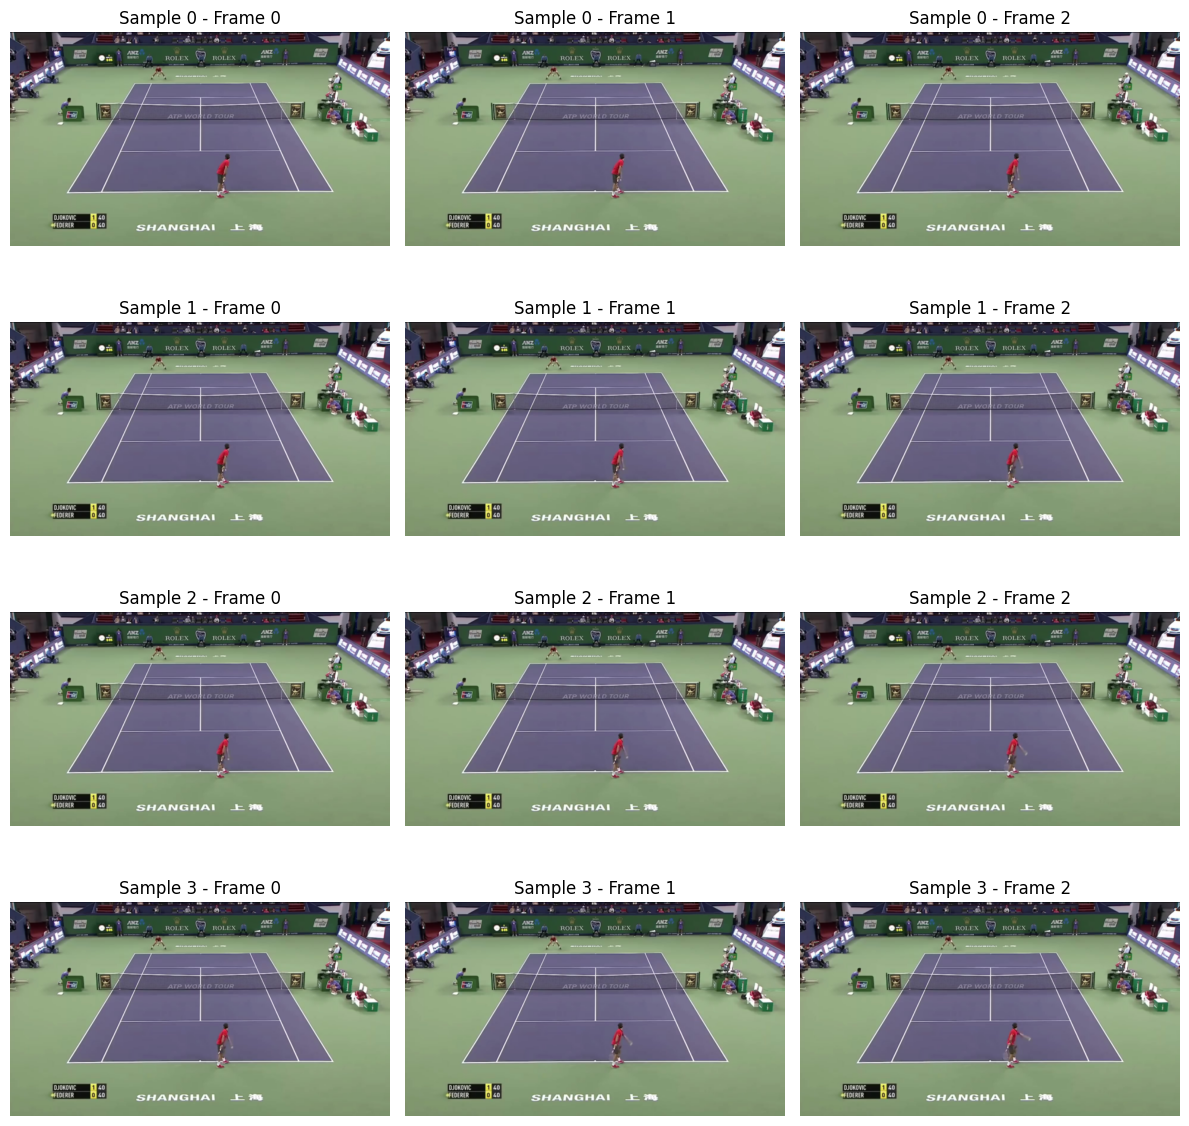

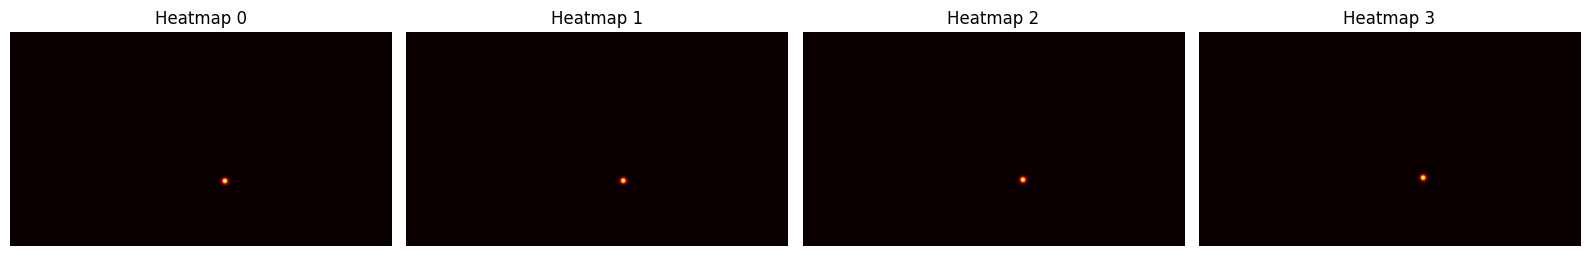

In [2]:

# Chat generated
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from dataloader import BallDataset

nb_input_frames = 3

dataset = BallDataset(train=False, nb_input_frames=nb_input_frames)
loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=2)

# Get one batch
imgs, heatmaps = next(iter(loader))

print(f"Dataset size: {len(dataset)}")
print(f"Input batch shape: {imgs.shape}")       # (B, 3*nb_input_frames, H, W)
print(f"Heatmap batch shape: {heatmaps.shape}") # (B, 1, H, W)

# Show first batch
fig, axes = plt.subplots(4, nb_input_frames, figsize=(4 * nb_input_frames, 12))

for i in range(4):
    # imgs[i] has shape [3*nb_input_frames, H, W]
    sample = imgs[i]

    for t in range(nb_input_frames):
        frame = sample[t*3:(t+1)*3]              # [3, H, W]
        frame = frame.permute(1, 2, 0) * 0.5 + 0.5
        axes[i, t].imshow(frame.numpy())
        axes[i, t].axis("off")
        axes[i, t].set_title(f"Sample {i} - Frame {t}")

plt.tight_layout()
plt.show()

# Show heatmaps separately
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
    axes[i].imshow(heatmaps[i].squeeze(0).numpy(), cmap="hot")
    axes[i].axis("off")
    axes[i].set_title(f"Heatmap {i}")

plt.tight_layout()
plt.show()